[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link] [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link] [![JupyterHub](https://img.shields.io/badge/Jupyter_Hub-orange?style=for-the-badge)][jupyter-link]

[download-link]: https://github.com/nmfs-opensci/nmfshackdays-2026/blob/main/topics/2026-04-17/erddap_xarray.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/nmfshackdays-2026/blob/main/topics/2026-04-17/erddap_xarray.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/nmfshackdays-2026/main/topics/2026-04-17/erddap_xarray.ipynb


>📘 Learning Objectives
>
> 1. Load ERDDAP data with xarray
> 2. Use some `xarray` functions on data cubes

## Overview

ERDDAP provides two data access modes: griddap for multidimensional gridded datasets that can be sliced by dimensions (e.g., time, latitude, longitude), and tabledap for tabular datasets that are queried by filtering rows (e.g., observations or profiles).

We can open ERDDAP gridded dataset collections with `xarray`. ERDDAP automatically creates an aggregated metadata layer that combines all granules in a collection. We can then call `xarray.open_dataset(collection_url)` to get a data cube without having to point to all the individual files. Make sure that the collection url points to the dataset without any subsetting specification. Under the hood, `xarray` will load the collection metadata (lazily). After loading, you can subset the full collection data as needed.

We will use the [Multi-scale Ultra-high Resolution (MUR) SST Analysis fv04.1, Global, 0.01°, 2002-present, Daily](https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41.html) data from NASA JPL. This is a high-resolution dataset of over 150 terabytes.

#### For those not working in the JupyterHub

Create a code cell and run `pip install xarray`.

## Load the data set (lazily)

In [1]:
import xarray as xr
url = "https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41"
ds = xr.open_dataset(url)
print(f"Size in TB: {ds.nbytes / 1e12:.2f} TB")
ds.sizes

Size in TB: 158.19 TB


Frozen({'time': 8719, 'latitude': 17999, 'longitude': 36000})

In [2]:
ds

<xarray.Dataset> Size: 158TB
Dimensions:           (time: 8719, latitude: 17999, longitude: 36000)
Coordinates:
  * time              (time) datetime64[ns] 70kB 2002-06-01T09:00:00 ... 2026...
  * latitude          (latitude) float32 72kB -89.99 -89.98 ... 89.98 89.99
  * longitude         (longitude) float32 144kB -180.0 -180.0 ... 180.0 180.0
Data variables:
    analysed_sst      (time, latitude, longitude) float64 45TB ...
    analysis_error    (time, latitude, longitude) float64 45TB ...
    mask              (time, latitude, longitude) float32 23TB ...
    sea_ice_fraction  (time, latitude, longitude) float64 45TB ...
Attributes: (12/51)
    _NCProperties:              version=2,netcdf=4.7.4,hdf5=1.8.12
    acknowledgement:            Please acknowledge the use of these data with...
    cdm_data_type:              Grid
    comment:                    MUR = "Multi-scale Ultra-high Resolution"
    Conventions:                CF-1.6, COARDS, ACDD-1.3
    creator_email:              ghrsst@podaac.jpl.nasa.gov
    ...                         ...
    summary:                    This is a merged, multi-sensor L4 Foundation ...
    testOutOfDate:              now-3days
    time_coverage_end:          2026-04-16T09:00:00Z
    time_coverage_start:        2002-06-01T09:00:00Z
    title:                      Multi-scale Ultra-high Resolution (MUR) SST A...
    Westernmost_Easting:        -179.99

## Subset this data set

First we will select the SST variable, subset to a 2 degree box and 1 year of data. This will create a much smaller data set or 120 Mb.

In [3]:
dc = ds['analysed_sst'].sel(
                        latitude=slice(33.5, 35.5), 
                        longitude=slice(-75.5, -73.5), 
                        time=slice('2003-01-01', '2003-12-31'))
print(f"Size in GB: {dc.nbytes / 1e9:.2f} GB")
dc.sizes

Size in GB: 0.12 GB


Frozen({'time': 365, 'latitude': 201, 'longitude': 201})

In [4]:
%%time
# Load the data into memory so the next steps are fast
dc.load();

CPU times: user 1.06 s, sys: 515 ms, total: 1.57 s
Wall time: 3min 19s


## Plot one day

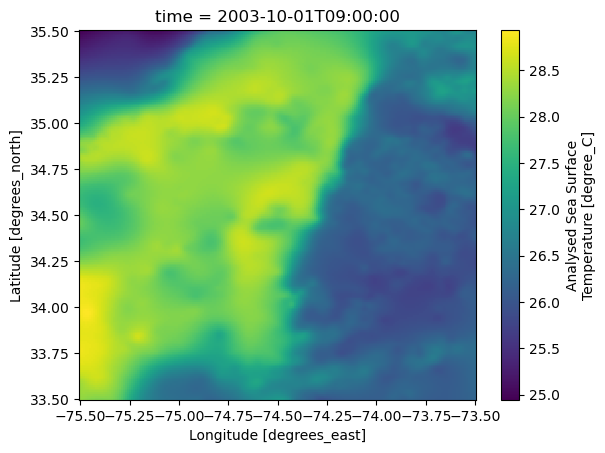

In [5]:
dc.sel(time="2003-10-01").plot();

## Compute the mean SST over the whole data set

Computing the mean for an data array returns a data array and here `.item()` is used to just return the value.

In [6]:
dc.mean().item()

24.800616488809275

### We can plot the spatial mean raster

We do this by taking the mean over the time dimension.

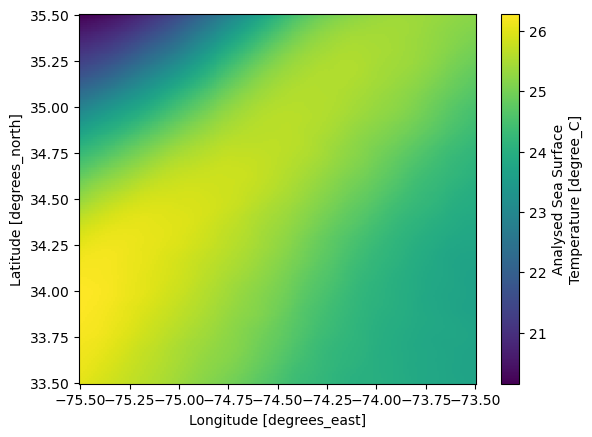

In [7]:
dc.mean(dim=['time']).plot();

### We can plot the daily means

We do this by taking the mean over the space dimensions.

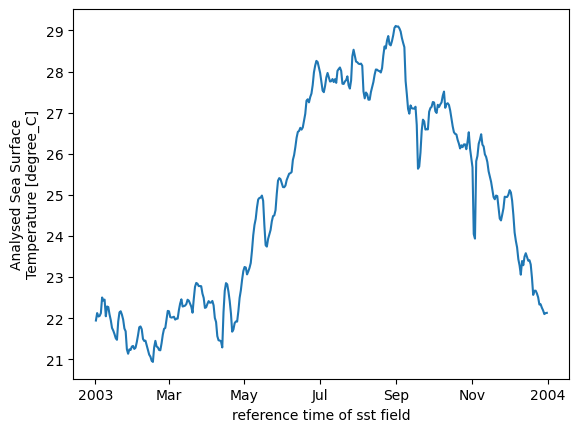

In [8]:
dc.mean(dim=['latitude', 'longitude']).plot();

## Resample to create monthly means

The `resample` function takes a long time if you don't have the data loaded in memory already. So you will want to run something like `dc.load()` (or `dc.mean()` or `dc.compute()`) before running the resample code.

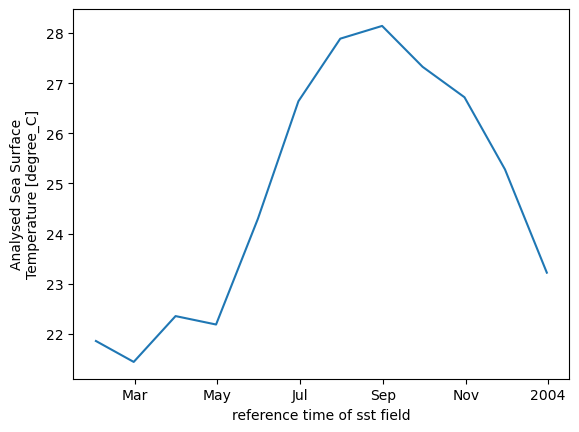

In [9]:
dc_monthly = dc.resample(time='ME').mean()
dc_monthly.mean(dim=['latitude', 'longitude']).plot();

## Chunking to do larger than memory computations

If we load in all the days for our 2 degree square, it is 2.7 Gb and larger than the memory on the small virtual machines (2 Gb). If we run the daily mean code, it would load all that data into memory and crash the kernel. In addition, ERDDAP has a 2Gb per request limit and we will run into that limit also.  We can use `dask` and chunking to do the calculation in smaller chunks so we don't run out of memory or run into download per request limits.

In [10]:
dc_all = ds['analysed_sst'].sel(
                        latitude=slice(33.5, 35.5), 
                        longitude=slice(-75.5, -73.5))

In [11]:
print(f"Size in GB: {dc_all.nbytes / 1e9:.2f} GB")
dc_all.sizes

Size in GB: 2.82 GB


Frozen({'time': 8719, 'latitude': 201, 'longitude': 201})

Use dask to chunk the data into 500 day chunks. Now when we process the data, it will load only one chunk at a time. We can (slowly) work through all the chunks without maxing out the data.

In [12]:
import dask
dc_chunk = dc_all.chunk({'time': 500, 'latitude': -1, 'longitude': -1})
dc_chunk

<xarray.DataArray 'analysed_sst' (time: 8719, latitude: 201, longitude: 201)> Size: 3GB
dask.array<xarray-<this-array>, shape=(8719, 201, 201), dtype=float64, chunksize=(500, 201, 201), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 70kB 2002-06-01T09:00:00 ... 2026-04-16T...
  * latitude   (latitude) float32 804B 33.5 33.51 33.52 ... 35.48 35.49 35.5
  * longitude  (longitude) float32 804B -75.5 -75.49 -75.48 ... -73.51 -73.5
Attributes:
    colorBarMaximum:  32.0
    colorBarMinimum:  0.0
    comment:          "Final" version using Multi-Resolution Variational Anal...
    ioos_category:    Temperature
    long_name:        Analysed Sea Surface Temperature
    source:           MODIS_T-JPL, MODIS_A-JPL, AMSR2-REMSS, AVHRRMTB_G-NAVO,...
    standard_name:    sea_surface_foundation_temperature
    units:            degree_C
    valid_max:        57.767
    valid_min:        -7.767000000000003

Here I will use just 3 years of data to illustrate the concept since chugging through all years would take awhile. but you can watch the memory (at the bottom nav bar in the Jupyter Hub) and see that it stays low. Note, 150 Mb chunks are a bit smaller than needed and we could speed things up by optimizing chunk size.

In [13]:
# This is takes about 13 minutes
from dask.diagnostics import ProgressBar

with ProgressBar():
    mean_all_years = dc_chunk.sel(time=slice("2002", "2006")).mean(dim=['latitude', 'longitude']).compute()

[########################################] | 100% Completed | 13m 49s


In [15]:
#mean_all_years.to_netcdf("mean_all_years.nc")

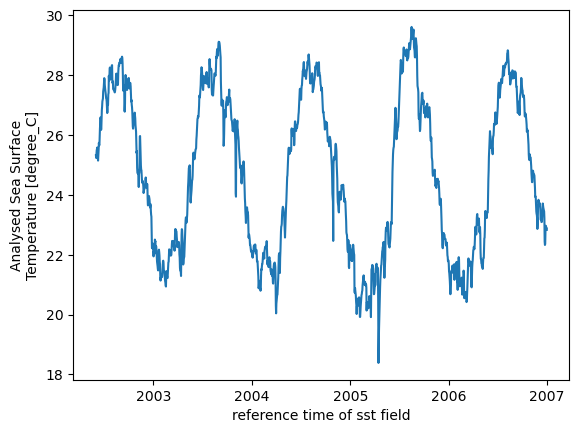

In [16]:
mean_all_years.plot();

We can resample to monthly.

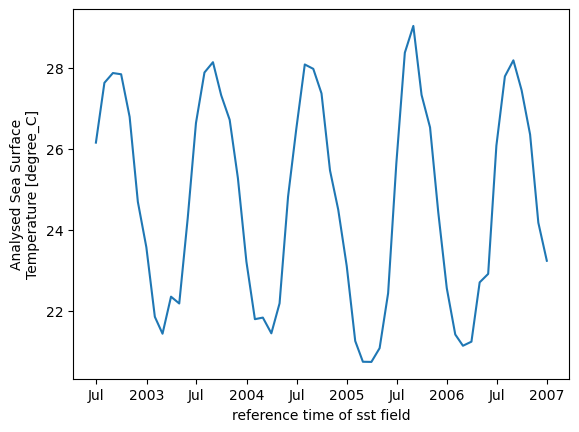

In [17]:
mean_all_years.resample(time='ME').mean().plot();

Note when we loaded all the data in, versus chunking with dask, running the `resample` code was fast because the data was already loaded. But with the chunked data, we don't keep all of it in memory so running `resample` would mean chugging through all the chunks again, i.e. would not be fast. Instead, above, the daily means were resampled to monthly instead of doing this:
```
dc_monthly = dc.resample(time='ME').mean()
```

## Compare to Zarr

This dataset is also available on AWS in Zarr format. This is a cloud-optimized format and computations with it are considerably faster.

In [1]:
import xarray
ds2 = xarray.open_zarr("https://mur-sst.s3.us-west-2.amazonaws.com/zarr-v1")

In [2]:
dc2 = ds2['analysed_sst'].sel(
                        lat=slice(33.5, 35.5), 
                        lon=slice(-75.5, -73.5),
                        time=slice('2003-01-01', '2006-12-31'))

Processing the Zarr dataset on AWS takes only 1.5 minutes versus 6 minutes with the data on ERDDAP.

In [3]:
import dask
dc2_chunk = dc2.chunk({'time': 500, 'lat': -1, 'lon': -1})
from dask.diagnostics import ProgressBar

with ProgressBar():
    mean_all_years = dc2_chunk.mean(dim=['lat', 'lon']).compute()

[########################################] | 100% Completed | 73.60 s


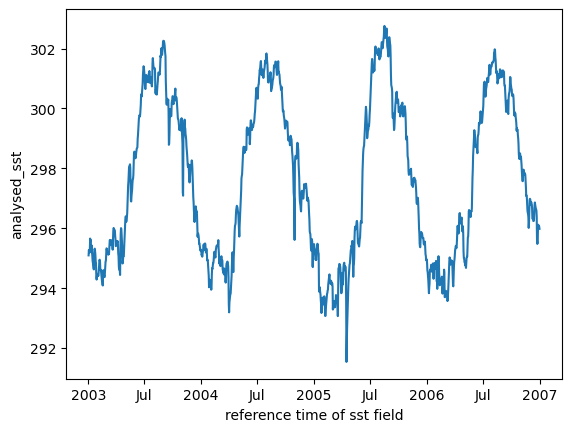

In [4]:
mean_all_years.plot();

## Summary

This tutorial shows you how to create xarray data cubes for gridded data from ERDDAP. The key is to use the url in the right format `<erddap server>/erddap/griddap/<collection id>` with no extra information like `.html` or time or space subsetting, or file type. 

Loading data available in Zarr format (a cloud-optimized format) works similarly and results in faster processing, but cloud-optimized data formats are still relatively uncommon.